## Downloading the xView2 Challenge Dataset

cd /media/data/building_instance_tamu

# Download Challenge Training Set (~7.8GB)
wget -O xview2_challenge_train.tar.gz "https://download.xview2.org/train_images_labels_targets.tar.gz?Expires=1765262052&Signature=M3lIwqrc0JecCK6H32orH-jMk8opKnV1s9FPtx8jKhylJ3SdTR3iqVnGne67gKLGoe8AWESvzv2Xb4mclwKZTlxYXltAC2gVlFUDIR69zkbbxBeDoXPJlAWz8NWpnPSsCd-wzEscxn8fpCKkLULNfK4PRm~7VRp-3y~vSejYNjxFDDh8vCQKSO9FLWXAMVuoKlWV8pvm0J74vlw09fhOrLZZHatfIZTZT8IsAWIlJIryfXKeZ-H49jBFmtNA7drENkMlyy8LYLoYF7KvAcB8z3556t5k741iNPtZZB96ysJID-MAcyuPWTV0zmHOQofv5~ekMBucZtmRI5H7rgXuiA__&Key-Pair-Id=APKAIKGDJB5C3XUL2DXQ"

# Download Challenge Test Set (~2.6GB)
wget -O xview2_challenge_test.tar.gz "https://download.xview2.org/test_images_labels_targets.tar.gz?Expires=1765262052&Signature=Wz5PVfIdKaX6woXw1VuR0BhK5zlwNeHukgyQJpdlfbOytsUNDq-KD4JkqCNqMxXng9o8LiIWSMg-bp7CX9xaou5foBCyZb71YtPp9JsNeceoLv2vBe70ryc2qUkwRBFWpDFUiE1k90FnMkTg0nMMqLZa2tTFJp3aar7M8JI5ZUHq0icJYvVmE8Gw7y-JISNTu3qPYD13SSUpJey0suwr1XkzOQIP4TRtslQa8ddj74XJu4wBRoP-4o0aJqQi5WtQUsM7WcbZaYyAoMvKuBZPIyj-jHaSIEmFlBdtBy-Vf87wo9Y56gKxG6cseYGgkmt1AeQu8A0eGbxx2uWmVAroAQ__&Key-Pair-Id=APKAIKGDJB5C3XUL2DXQ"


In [ ]:
cd /media/data/building_instance_tamu

tar -xvzf xview2_challenge_train.tar.gz

tar -xvzf xview2_challenge_test.tar.gz

## Data EDA 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import random
import os

In [5]:
base = "/media/data/building_instance_tamu/test"
prefix = "hurricane-florence_00000005"

pre_label_path  = f"{base}/labels/{prefix}_pre_disaster.json"
post_label_path = f"{base}/labels/{prefix}_post_disaster.json"

def analyze_json(path):
    with open(path, "r") as f:
        data = json.load(f)

    feature_types = []
    subtypes = []
    uids = []

    # The structure is: data["features"]["xy"] or data["features"]["lng_lat"]
    # We will check both if they exist.
    for key in ["xy", "lng_lat"]:
        if key not in data["features"]:
            continue
        
        for feat in data["features"][key]:
            props = feat["properties"]
            feature_types.append(props.get("feature_type", None))
            subtypes.append(props.get("subtype", None))   # Pre-disaster may be missing
            uids.append(props.get("uid", None))

    return {
        "feature_types": set(feature_types),
        "subtypes": set(subtypes),
        "uids_count": len(set(uids))
    }

pre_info  = analyze_json(pre_label_path)
post_info = analyze_json(post_label_path)

print("===== PRE-DISASTER JSON =====")
print("Feature types:", pre_info["feature_types"])
print("Subtypes:", pre_info["subtypes"])       # Usually {None}
print("Unique buildings:", pre_info["uids_count"])

print("\n===== POST-DISASTER JSON =====")
print("Feature types:", post_info["feature_types"])
print("Subtypes:", post_info["subtypes"])      # Expected: {'no-damage','minor-damage',...}
print("Unique buildings:", post_info["uids_count"])


===== PRE-DISASTER JSON =====
Feature types: {'building'}
Subtypes: {None}
Unique buildings: 77

===== POST-DISASTER JSON =====
Feature types: {'building'}
Subtypes: {'no-damage', 'un-classified'}
Unique buildings: 77


PRE mask unique: [0 1]
POST mask unique: [0 1 3 4]


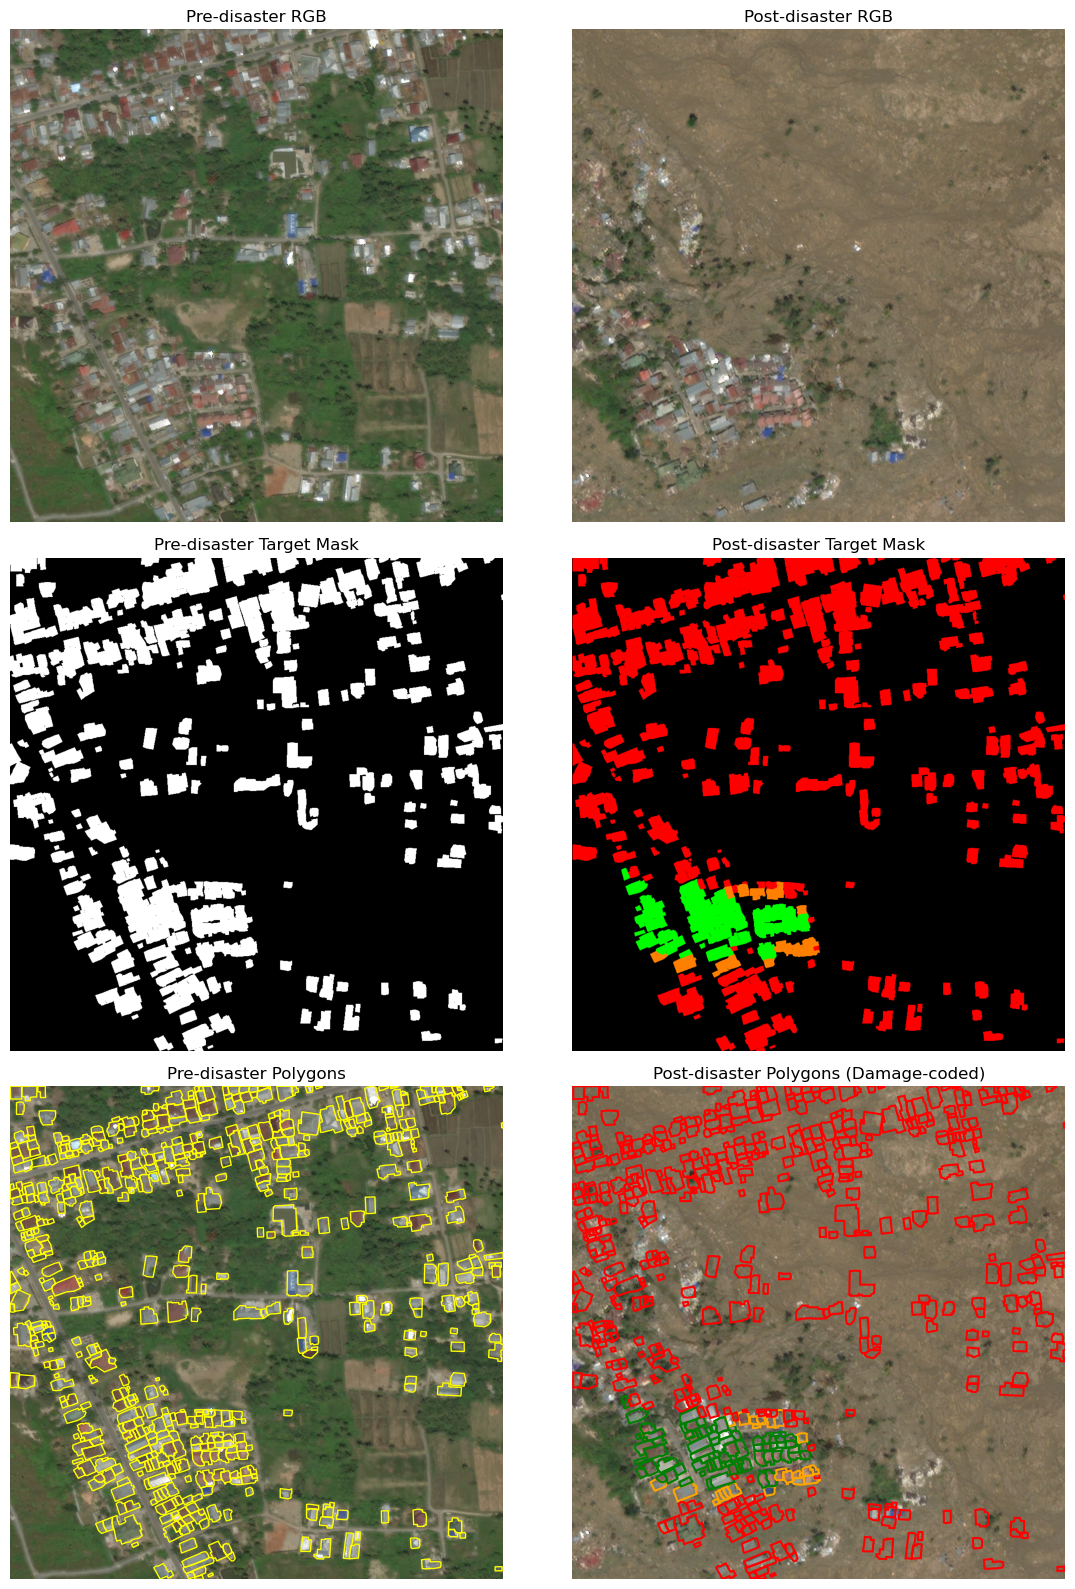

In [37]:
base = "/media/data/building_instance_tamu/train"

prefix = "santa-rosa-wildfire_00000285"
#prefix = "hurricane-florence_00000384"
#prefix = "hurricane-florence_00000005"
#prefix = "socal-fire_00000504"

Random = True
if Random:
    prefix = random.choice([
        f.replace("_pre_disaster.png", "")
        for f in os.listdir(f"{base}/images")
        if f.endswith("_pre_disaster.png")
    ])

# Paths
pre_img_path = f"{base}/images/{prefix}_pre_disaster.png"
post_img_path = f"{base}/images/{prefix}_post_disaster.png"

pre_mask_path = f"{base}/targets/{prefix}_pre_disaster_target.png"
post_mask_path = f"{base}/targets/{prefix}_post_disaster_target.png"

pre_label_path = f"{base}/labels/{prefix}_pre_disaster.json"
post_label_path = f"{base}/labels/{prefix}_post_disaster.json"

# Load data
pre_img = np.array(Image.open(pre_img_path))
post_img = np.array(Image.open(post_img_path))
pre_mask = np.array(Image.open(pre_mask_path))
post_mask = np.array(Image.open(post_mask_path))

print("PRE mask unique:", np.unique(pre_mask))
print("POST mask unique:", np.unique(post_mask))

# ---------------------------------------
#  CUSTOM COLORMAPS
# ---------------------------------------

# Pre-disaster: 0=black, 1=white
pre_cmap = ListedColormap([
    (0, 0, 0),   # 0 background
    (1, 1, 1)    # 1 building
])

# Post-disaster: 0–5 mapping
post_cmap = ListedColormap([
    (0, 0, 0),      # 0 background
    (0, 1, 0),      # 1 green (no-damage)
    (1, 1, 0),      # 2 yellow (minor)
    (1, 0.5, 0),    # 3 orange (major)
    (1, 0, 0),      # 4 red (destroyed)
    (1, 1, 1)       # 5 white (un-classified)
])


# ---------------------------------------
#  FIGURE LAYOUT
# ---------------------------------------
fig, axs = plt.subplots(3, 2, figsize=(12, 16))

# ---------------- Row 1: RGB IMAGES ----------------
axs[0, 0].imshow(pre_img)
axs[0, 0].set_title("Pre-disaster RGB")
axs[0, 0].axis("off")

axs[0, 1].imshow(post_img)
axs[0, 1].set_title("Post-disaster RGB")
axs[0, 1].axis("off")

# ---------------- Row 2: TARGET MASKS ----------------
axs[1, 0].imshow(pre_mask, cmap=pre_cmap, vmin=0, vmax=1)
axs[1, 0].set_title("Pre-disaster Target Mask")
axs[1, 0].axis("off")

axs[1, 1].imshow(post_mask, cmap=post_cmap, vmin=0, vmax=5)
axs[1, 1].set_title("Post-disaster Target Mask")
axs[1, 1].axis("off")

# ---------------- Row 3: POLYGON LABELS ----------------
# PRE polygons
axs[2, 0].imshow(pre_img)
axs[2, 0].set_title("Pre-disaster Polygons")
axs[2, 0].axis("off")

with open(pre_label_path, "r") as f:
    pre_data = json.load(f)

for feat in pre_data["features"]["xy"]:
    poly = feat["wkt"].replace("POLYGON ((", "").replace("))", "")
    coords = [tuple(map(float, p.split())) for p in poly.split(",")]
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    polygon = patches.Polygon(list(zip(xs, ys)),
                              fill=False, edgecolor="yellow", linewidth=1)
    axs[2, 0].add_patch(polygon)


# POST polygons (damage-colored)
axs[2, 1].imshow(post_img)
axs[2, 1].set_title("Post-disaster Polygons (Damage-coded)")
axs[2, 1].axis("off")

damage_colors = {
    "no-damage": "green",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
    "un-classified": "pink"   # <-- FIXED
}

with open(post_label_path, "r") as f:
    post_data = json.load(f)

for feat in post_data["features"]["xy"]:
    subtype = feat["properties"]["subtype"]
    color = damage_colors.get(subtype, "white")   # fallback = white

    poly = feat["wkt"].replace("POLYGON ((", "").replace("))", "")
    coords = [tuple(map(float, p.split())) for p in poly.split(",")]
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]

    polygon = patches.Polygon(list(zip(xs, ys)),
                              fill=False, edgecolor=color, linewidth=1.5)
    axs[2, 1].add_patch(polygon)

plt.tight_layout()
plt.show()